In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import collections

In [ ]:
base_dir = Path(r'')
collection_names = ["messages", "questionbanks", "lba_questions", "useractions"]

In [22]:
def extract_timestamps(file_name):
    file_path = base_dir / f"{file_name}.json"
    timestamps = []
    
    if not file_path.exists():
        print(f"File not found: {file_path}")
        return []
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:
                doc = json.loads(line)
                created_at = doc.get('createdAt')
                if isinstance(created_at, dict):
                    ts = created_at.get('$date')
                else:
                    ts = created_at
                
                if ts:
                    timestamps.append(ts)
            except:
                continue
    return timestamps

def load_flattened_json(filename):
    rows = []
    file_path = base_dir / filename
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if not line.strip(): continue
            doc = json.loads(line)
            flat = {}
            for k, v in doc.items():
                if isinstance(v, dict):
                    if '$oid' in v: flat[k] = v['$oid']
                    elif '$date' in v: flat[k] = v['$date']
                    else: flat[k] = str(v)
                else:
                    flat[k] = v
            rows.append(flat)
    return pd.DataFrame(rows)

In [20]:
all_series = []
for col in collection_names:
    ts_list = extract_timestamps(col)
    if ts_list:
        df_temp = pd.DataFrame({'timestamp': pd.to_datetime(ts_list, format='ISO8601', errors='coerce')})
        monthly_count = df_temp.resample('ME', on='timestamp').size()
        monthly_count.name = col
        all_series.append(monthly_count)
usage_df = pd.concat(all_series, axis=1).fillna(0)

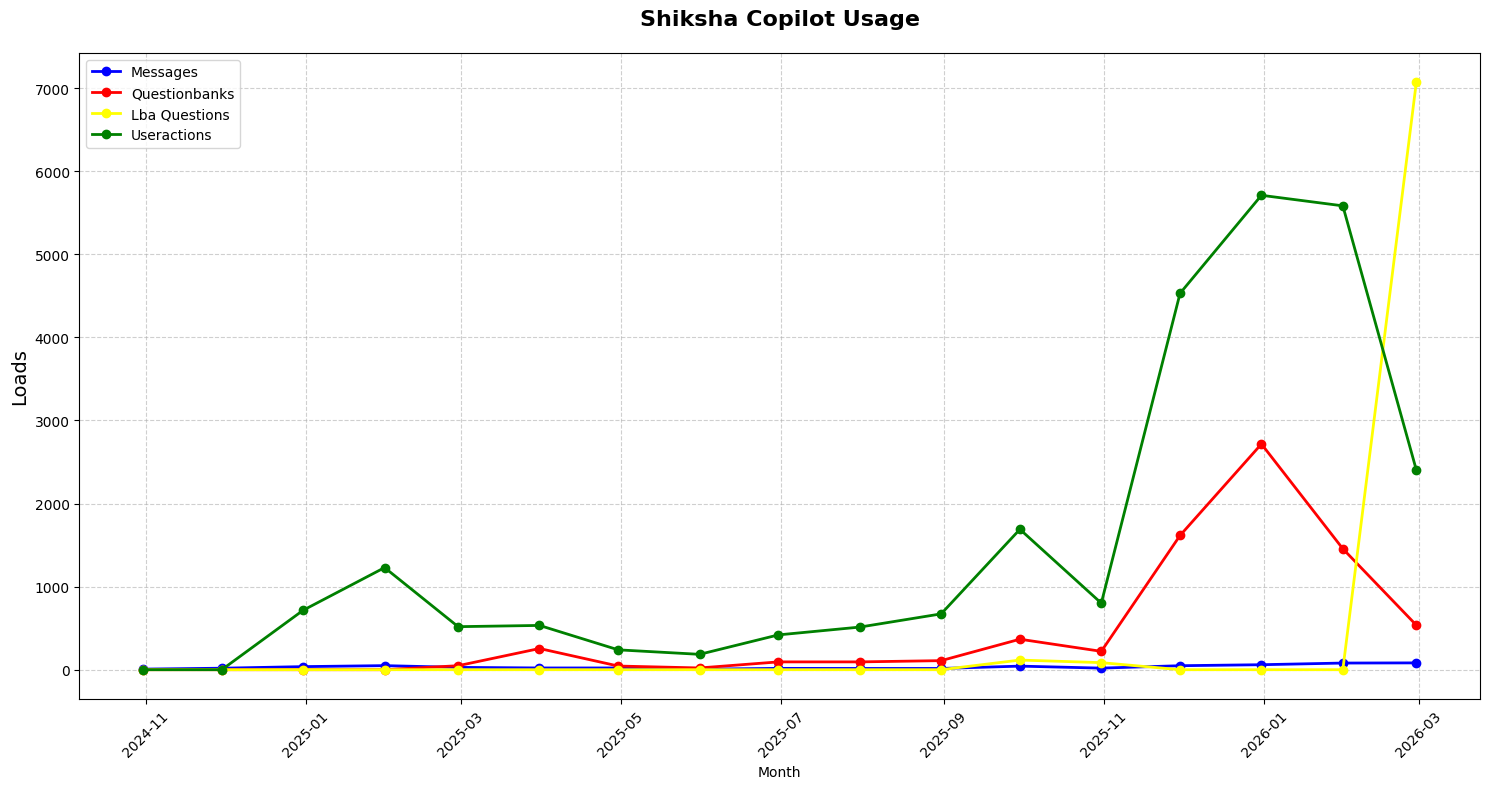

In [18]:
plt.figure(figsize=(15, 8))

colors = {'messages': 'blue', 'questionbanks': 'red', 'lba_questions': 'yellow', 'useractions': 'green'}

for col in usage_df.columns:
    plt.plot(usage_df.index, usage_df[col], marker='o', label=col.replace('_', ' ').title(), linewidth=2, color=colors.get(col))
plt.title("Shiksha Copilot Usage", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Loads", fontsize=14)
plt.xlabel("Month")
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
activities_df = load_flattened_json("useractivities.json")
users_df = load_flattened_json("users.json")

merged_df = pd.merge(
    activities_df, 
    users_df[['_id', 'zone', 'district', 'state']], 
    left_on='userId', 
    right_on='_id', 
    how='left'
)

merged_df['createdAt'] = pd.to_datetime(merged_df['createdAt'], format='ISO8601', errors='coerce')
merged_df = merged_df.dropna(subset=['createdAt', 'zone', 'moduleName'])
merged_df['month'] = merged_df['createdAt'].dt.to_period('M').dt.to_timestamp()
agg_df = merged_df.groupby(['month', 'zone', 'moduleName']).size().reset_index(name='activity_count')

C:\Users\adity\AppData\Local\Temp\ipykernel_11476\2200100980.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  merged_df['month'] = merged_df['createdAt'].dt.to_period('M').dt.to_timestamp()


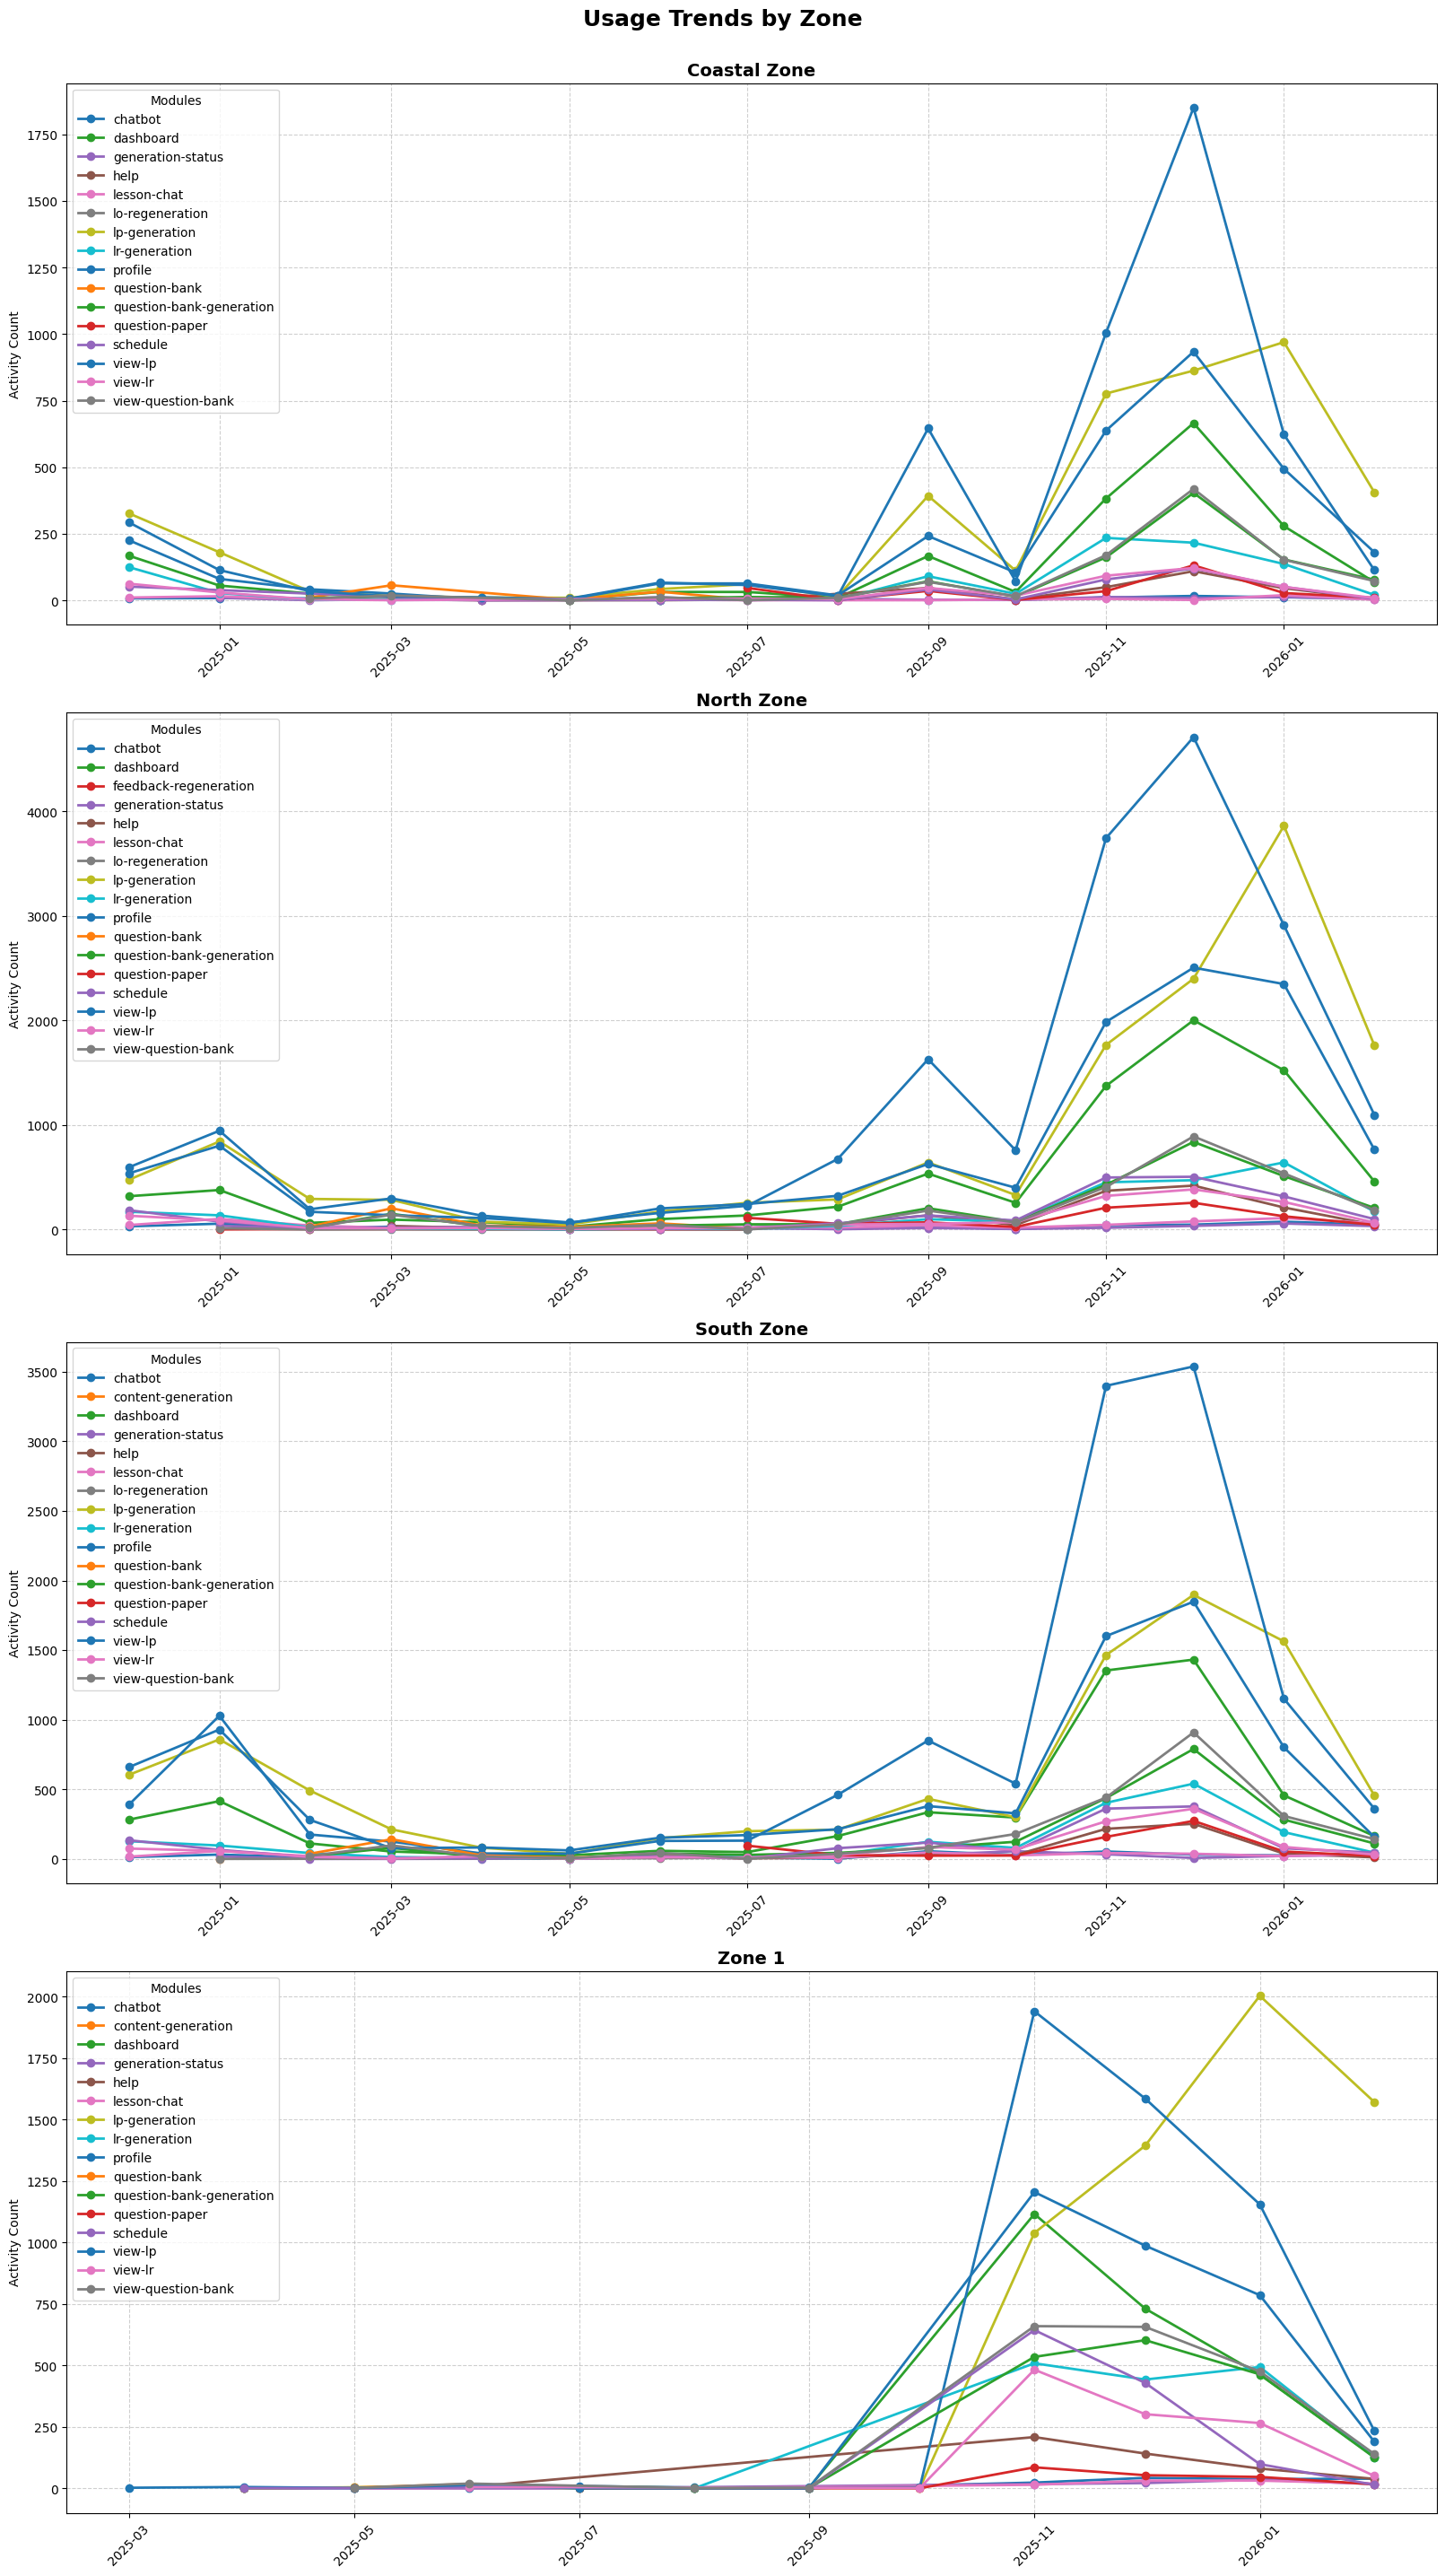

In [33]:
import matplotlib.pyplot as plt

# 1. Colors extracted from your attached plot/standard palette
# Blue: #1f77b4, Orange: #ff7f0e, Green: #2ca02c, Red: #d62728, Purple: #9467bd
module_colors = {
    'view-lp': '#1f77b4',
    'generate-questions': '#ff7f0e',
    'view-qb': '#2ca02c',
    'chat': '#d62728',
    'lesson-plan-create': '#9467bd',
    'feedback': '#8c564b',
    'useractions': '#e377c2'
}
default_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

zones = sorted(agg_df['zone'].unique())
n_zones = len(zones)
cols = 1
rows = n_zones
fig, axes = plt.subplots(rows, cols, figsize=(16, 7 * rows), constrained_layout=True)
axes = axes.flatten()
all_modules = sorted(agg_df['moduleName'].unique())

for i, zone in enumerate(zones):
    ax = axes[i]
    zone_df = agg_df[agg_df['zone'] == zone]
    for j, module in enumerate(all_modules):
        mod_df = zone_df[zone_df['moduleName'] == module].sort_values('month')
        if not mod_df.empty:
            color = module_colors.get(module, default_cycle[j % len(default_cycle)])
            
            ax.plot(mod_df['month'], mod_df['activity_count'], 
                    marker='o', 
                    label=module, 
                    color=color,
                    linewidth=2)
    
    ax.set_title(f"{zone}", fontweight='bold', fontsize=14)
    ax.set_ylabel("Activity Count")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10, loc='upper left', frameon=True, title="Modules")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Usage Trends by Zone", fontsize=18, fontweight='bold', y=1.02)
plt.show()